<a href="https://colab.research.google.com/github/ashleybrea/Weighted-Scales-Demographic-Disparities-in-NYPD-Arrests/blob/main/ML_Project_Progress_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import sklearn as sk
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Processing (mostly centralized besides in Logistic Regression section)**

In [ ]:
# reading NY ARRESTS
nyar_df = pd.read_csv('/content/sample_data/NYPD_Arrests_Data_ML.csv',on_bad_lines="warn",engine='python')

nyar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2374606 entries, 0 to 2374605
Data columns (total 19 columns):
 #   Column             Dtype  
---  ------             -----  
 0   ARREST_KEY         int64  
 1   ARREST_DATE        object 
 2   PD_CD              float64
 3   PD_DESC            object 
 4   KY_CD              float64
 5   OFNS_DESC          object 
 6   LAW_CODE           object 
 7   LAW_CAT_CD         object 
 8   ARREST_BORO        object 
 9   ARREST_PRECINCT    int64  
 10  JURISDICTION_CODE  int64  
 11  AGE_GROUP          object 
 12  PERP_SEX           object 
 13  PERP_RACE          object 
 14  X_COORD_CD         float64
 15  Y_COORD_CD         float64
 16  Latitude           float64
 17  Longitude          float64
 18  Lon_Lat            object 
dtypes: float64(6), int64(3), object(10)
memory usage: 344.2+ MB


In [ ]:
# selecting cols
nyar_df = nyar_df[['ARREST_DATE','ARREST_BORO','ARREST_PRECINCT','AGE_GROUP','PERP_SEX','PERP_RACE', 'LAW_CAT_CD']]

# cleaning empty rows
nyar_df = nyar_df.dropna()

In [ ]:
# updating ARREST_DATE into datetime
nyar_df['ARREST_DATE'] = pd.to_datetime(nyar_df['ARREST_DATE'])

In [ ]:
# updating 'object' to 'category'
for col in ['ARREST_BORO','ARREST_PRECINCT','AGE_GROUP','PERP_SEX','PERP_RACE','LAW_CAT_CD']:
    nyar_df[col] = nyar_df[col].astype('category')

nyar_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2359623 entries, 0 to 2374605
Data columns (total 7 columns):
 #   Column           Dtype         
---  ------           -----         
 0   ARREST_DATE      datetime64[ns]
 1   ARREST_BORO      category      
 2   ARREST_PRECINCT  category      
 3   AGE_GROUP        category      
 4   PERP_SEX         category      
 5   PERP_RACE        category      
 6   LAW_CAT_CD       category      
dtypes: category(6), datetime64[ns](1)
memory usage: 49.5 MB


In [ ]:
# filtering arrests of minors from database
nyar_df = nyar_df[nyar_df['AGE_GROUP'] != '<18']

In [ ]:
# converting boroughs to variables that are discrete
nyar_df['IS_QUEENS'] = np.where(nyar_df['ARREST_BORO'] == 'Q', '1', '0')
nyar_df['IS_BRONX'] = np.where(nyar_df['ARREST_BORO'] == 'Q', '1', '0')
nyar_df['IS_MANH'] = np.where(nyar_df['ARREST_BORO'] == 'M', '1', '0')
nyar_df['IS_BROOK'] = np.where(nyar_df['ARREST_BORO'] == 'K', '1', '0')
nyar_df['IS_STATEN'] = np.where(nyar_df['ARREST_BORO'] == 'S', '1', '0')

In [ ]:
# converting ages to variables that are discrete
nyar_df['IS_18_TO_24'] = np.where(nyar_df['AGE_GROUP'] == '18-24', '1', '0')
nyar_df['IS_25_TO_44'] = np.where(nyar_df['AGE_GROUP'] == '25-44', '1', '0')
nyar_df['IS_45_TO_64'] = np.where(nyar_df['AGE_GROUP'] == '45-64', '1', '0')
nyar_df['IS_65_PLUS'] = np.where(nyar_df['AGE_GROUP'] == '65+', '1', '0')

In [ ]:
# convert sex to dummy encoding
nyar_df['IS_MALE'] = np.where(nyar_df['PERP_SEX'] == 'M', '1', '0')

In [ ]:
# convert race to dummy encoding
nyar_df['IS_BLACK_HISPANIC'] = np.where(nyar_df['PERP_RACE'] == 'BLACK HISPANIC', '1', '0')
nyar_df['IS_BLACK'] = np.where(nyar_df['PERP_RACE'] == 'BLACK', '1', '0')
nyar_df['IS_WHITE_HISPANIC'] = np.where(nyar_df['PERP_RACE'] == 'WHITE HISPANIC', '1', '0')
nyar_df['IS_WHITE'] = np.where(nyar_df['PERP_RACE'] == 'WHITE', '1', '0')
nyar_df['IS_AAPI'] = np.where(nyar_df['PERP_RACE'] == 'ASIAN / PACIFIC ISLANDER', '1', '0')
nyar_df['IS_AM_IN_AK_NA'] = np.where(nyar_df['PERP_RACE'] == 'AMERICAN INDIAN/ALASKAN NATIVE', '1', '0')
nyar_df['RACE_IS_UNKNOWN'] = np.where(nyar_df['PERP_RACE'] == 'UNKOWN', '1', '0')

In [ ]:
nyar_df = nyar_df[~nyar_df['LAW_CAT_CD'].isin(['(null)', 9, 'I'])]
nyar_df['IS_F'] = np.where(nyar_df['LAW_CAT_CD'] == 'F', '1', '0')
nyar_df['IS_V'] = np.where(nyar_df['LAW_CAT_CD'] == 'V', '1', '0')
nyar_df['IS_M'] = np.where(nyar_df['LAW_CAT_CD'] == 'M', '1', '0')

In [ ]:
nyar_df['date_col'] = pd.to_datetime(nyar_df['ARREST_DATE'], format='mixed')
nyar_df['date_col'] = nyar_df['date_col'].dt.year
# only the years 2019 and 2020 for now
nyar_df = nyar_df[nyar_df['date_col'].isin([2019, 2020])]

In [ ]:
nyar_df.head(5)

,ARREST_DATE,ARREST_BORO,ARREST_PRECINCT,AGE_GROUP,PERP_SEX,PERP_RACE,LAW_CAT_CD,IS_QUEENS,IS_BRONX,IS_MANH,...,IS_BLACK,IS_WHITE_HISPANIC,IS_WHITE,IS_AAPI,IS_AM_IN_AK_NA,RACE_IS_UNKNOWN,IS_F,IS_V,IS_M,date_col
832656,2020-12-31,Q,103,25-44,M,WHITE HISPANIC,M,1,1,0,...,0,1,0,0,0,0,0,0,1,2020
832657,2020-12-31,Q,111,18-24,F,WHITE HISPANIC,F,1,1,0,...,0,1,0,0,0,0,1,0,0,2020
832658,2020-12-31,S,120,45-64,M,WHITE,F,0,0,0,...,0,0,1,0,0,0,1,0,0,2020
832659,2020-12-31,K,75,18-24,M,BLACK,F,0,0,0,...,1,0,0,0,0,0,1,0,0,2020
832661,2020-12-31,B,42,18-24,M,BLACK,F,0,0,0,...,1,0,0,0,0,0,1,0,0,2020


# **USING pandas.get_dummies()**

In [ ]:
nyar_df = pd.read_csv('/content/sample_data/NYPD_Arrests_Data_ML.csv',on_bad_lines="warn",engine='python')

nyar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2374606 entries, 0 to 2374605
Data columns (total 19 columns):
 #   Column             Dtype  
---  ------             -----  
 0   ARREST_KEY         int64  
 1   ARREST_DATE        object 
 2   PD_CD              float64
 3   PD_DESC            object 
 4   KY_CD              float64
 5   OFNS_DESC          object 
 6   LAW_CODE           object 
 7   LAW_CAT_CD         object 
 8   ARREST_BORO        object 
 9   ARREST_PRECINCT    int64  
 10  JURISDICTION_CODE  int64  
 11  AGE_GROUP          object 
 12  PERP_SEX           object 
 13  PERP_RACE          object 
 14  X_COORD_CD         float64
 15  Y_COORD_CD         float64
 16  Latitude           float64
 17  Longitude          float64
 18  Lon_Lat            object 
dtypes: float64(6), int64(3), object(10)
memory usage: 344.2+ MB


In [ ]:
# selecting cols
nyar_df = nyar_df[['ARREST_DATE','ARREST_BORO','AGE_GROUP','PERP_SEX','PERP_RACE','LAW_CAT_CD']]

# cleaning empty rows
nyar_df = nyar_df.dropna()


In [ ]:
dummies = pd.get_dummies(
    nyar_df[['AGE_GROUP', 'PERP_RACE', 'PERP_SEX', 'ARREST_BORO']],
    prefix=['AGE', 'RACE', 'SEX', 'BORO']
).astype(int)

nyar_df = pd.concat([nyar_df, dummies], axis=1)

In [ ]:
rename_map = {
    'AGE_18-24': 'IS_18_TO_24', # AGE COLS
    'AGE_25-44': 'IS_25_TO_44',
    'AGE_45-64': 'IS_45_TO_64',
    'AGE_65+': 'IS_65_PLUS',

    'RACE_BLACK HISPANIC': 'IS_BLACK_HISPANIC', # RACE COLS
    'RACE_BLACK': 'IS_BLACK',
    'RACE_WHITE HISPANIC': 'IS_WHITE_HISPANIC',
    'RACE_WHITE': 'IS_WHITE',
    'RACE_ASIAN / PACIFIC ISLANDER': 'IS_AAPI',
    'RACE_AMERICAN INDIAN/ALASKAN NATIVE': 'IS_AM_IN_AK_NA',
    'RACE_UNKNOWN': 'RACE_IS_UNKNOWN',

    'SEX_M': 'IS_MALE', # SEX COL

    'BORO_Q': 'IS_QUEENS', # BORO COL
    'BORO_B': 'IS_BRONX',
    'BORO_M': 'IS_MANH',
    'BORO_K': 'IS_BROOK',
    'BORO_S': 'IS_STATEN'
}

nyar_df = nyar_df.rename(columns=rename_map)

In [ ]:
# OTHER preprocessing

# filtering arrests of minors from database
nyar_df = nyar_df[nyar_df['AGE_GROUP'] != '<18']
# converting ARREST_DATE to binary discrete variable with just 2019 and 2020 datapoints
nyar_df['date_col'] = pd.to_datetime(nyar_df['ARREST_DATE'], format='mixed')
nyar_df = nyar_df[nyar_df['date_col'].dt.year.isin([2019, 2020])]

nyar_df = nyar_df[~nyar_df['LAW_CAT_CD'].isin(['(null)', 9, 'I'])]


# **Random Forest Classifier**


In [ ]:
# define features
X = ['IS_QUEENS','IS_BRONX','IS_MANH','IS_BROOK','IS_STATEN',
            'IS_18_TO_24','IS_25_TO_44','IS_45_TO_64','IS_65_PLUS',
            'IS_BLACK_HISPANIC','IS_BLACK','IS_WHITE_HISPANIC','IS_WHITE','IS_AAPI','IS_AM_IN_AK_NA', 'RACE_IS_UNKNOWN', 'IS_MALE']
X = nyar_df[X]

# define target
y = nyar_df['LAW_CAT_CD']

# train, test, split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train baseline Random Forest (changed to Classifier)
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

In [ ]:
# predictions
y_pred = rf.predict(X_test)

# accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# balanced accuracy
from sklearn.metrics import balanced_accuracy_score
balanced_acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy:", balanced_acc)

Accuracy: 0.5902934032693081
Balanced Accuracy: 0.3658645918937761


**Accuracy**: Model currently accuractly predicts about 59% of the time.

 **Balanced Accuracy**: Model is currently very biased toward predicting the most common class, Misdemeanors, and is behaving poorly on Felony and Violation

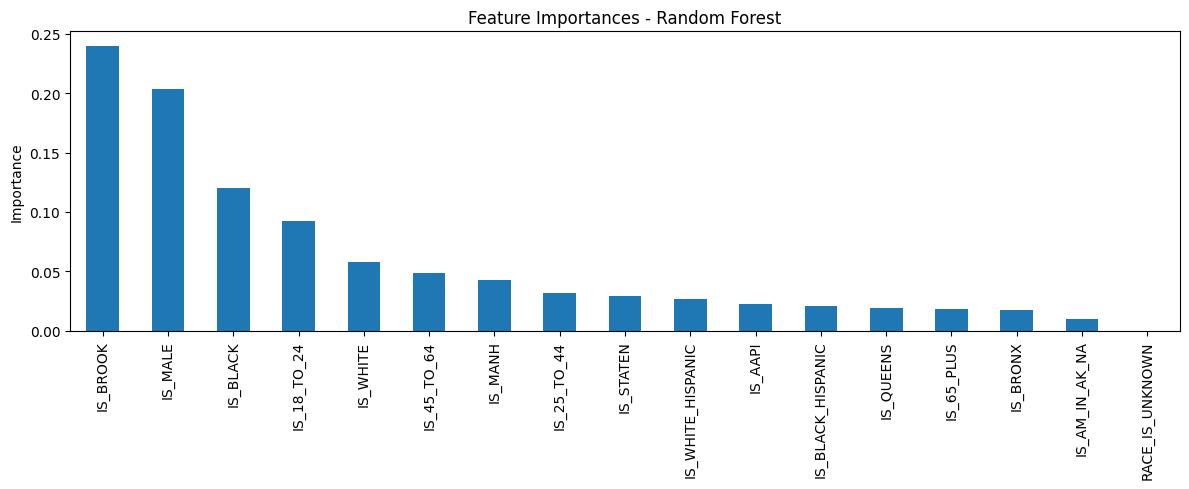

In [ ]:
import matplotlib.pyplot as plt

feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(12,5))
plt.title('Feature Importances - Random Forest')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
print(nyar_df['LAW_CAT_CD'].value_counts())
print(nyar_df['LAW_CAT_CD'].value_counts(normalize=True))

LAW_CAT_CD
M         193867
F         138336
V           3340
(null)         0
9              0
I              0
Name: count, dtype: int64
LAW_CAT_CD
M         0.577771
F         0.412275
V         0.009954
(null)    0.000000
9         0.000000
I         0.000000
Name: proportion, dtype: float64


There is a class imbalance with Misdeamors reresenting 58% of the dataset. To ensure this doesnt impact our model, i will add the class balance parameter.


In [ ]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Balanced Accuracy:", balanced_acc)

Accuracy: 0.42408618814168
Balanced Accuracy: 0.4712344792494396


In [ ]:
rf_tuned = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_estimators=200,      # more trees
    max_depth=10,          # limit depth to reduce overfitting
    min_samples_leaf=5     # require more samples per leaf
)
rf_tuned.fit(X_train, y_train)

y_pred_tuned = rf_tuned.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Tuned Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_tuned))

Tuned Accuracy: 0.4317006660805555
Tuned Balanced Accuracy: 0.47346303591205463


After tuning some more there hasn't been any more significant improvement in the accuracy scores. So I won't hypertune anymore, as I believe the features just don't have enough predictive power.

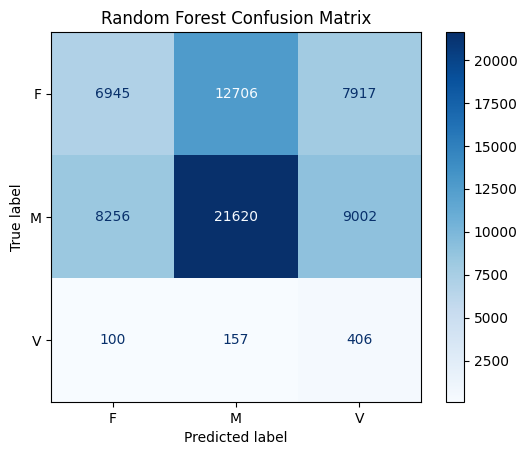

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_tuned, labels=['F', 'M', 'V'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['F', 'M', 'V'])
disp.plot(cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.show()

# **KNN**

In [ ]:
X = ['IS_QUEENS','IS_BRONX','IS_MANH','IS_BROOK','IS_STATEN',
            'IS_18_TO_24','IS_25_TO_44','IS_45_TO_64','IS_65_PLUS',
            'IS_BLACK_HISPANIC','IS_BLACK','IS_WHITE_HISPANIC','IS_WHITE','IS_AAPI','IS_AM_IN_AK_NA', 'RACE_IS_UNKNOWN', 'IS_MALE']
y = nyar_df['LAW_CAT_CD']
X = nyar_df[X]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

In [ ]:
for k in [1,3,10]:

  model_knn = KNeighborsClassifier(n_neighbors=k).fit(X_train,y_train)

  y_pred = model_knn.predict(X_test)

  print(f"k={k}:", sk.metrics.accuracy_score(y_pred, y_test))

k=1: 0.5235512375389292


In [ ]:
# Normalizing features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=.2)

In [ ]:
# Perforimg k exploration after scaling
for k in [1,3,10]:

  model_knn = KNeighborsClassifier(n_neighbors=k).fit(X_train,y_train)

  y_pred = model_knn.predict(X_test)

  print(f"k={k}:", sk.metrics.accuracy_score(y_pred, y_test))

In [ ]:
idx = np.random.choice(len(X_train), size=100000, replace=False)

X_sample = X_train[idx]
y_sample = y_train.iloc[idx]

In [ ]:
# 3-fold cross-validation
cv = KFold(n_splits=3, shuffle=True, random_state=342)

best_k = None
lowest_error = float("inf")

# loop over twenty times
for k in range(1, 21):

    # use StandardScaler() for centering
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    # error rate
    scores = cross_val_score(pipeline, X_sample, y_sample, cv=cv, scoring='accuracy',
        n_jobs=-1
    )

    mean_error = 1 - scores.mean()

    if mean_error < lowest_error:
        lowest_error = mean_error
        best_k = k

# fit final model using best k
best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])

best_model.fit(X_sample, y_sample)

print("Best k:", best_k)
print("Best CV Error Rate:", lowest_error)

In [ ]:
best_model = KNeighborsClassifier(n_neighbors=19).fit(X_train,y_train)

In [ ]:
y_pred = best_model.predict(X_test)
sk.metrics.accuracy_score(y_pred, y_test)

0.5583751806762133

In [ ]:
counts = y.value_counts()
print(counts)

LAW_CAT_CD
M    193867
F    138336
V      3340
Name: count, dtype: int64


In [ ]:
accuracy_by_group = (
    pd.DataFrame({
        'y_true': y_test,
        'y_pred': y_pred
    })
    .assign(correct=lambda d: d.y_true == d.y_pred)
    .groupby('y_true')['correct']
    .mean()
)

print(accuracy_by_group)

y_true
F    0.255780
M    0.763983
V    0.000000
Name: correct, dtype: float64


# **Logistic Regression**

In [ ]:
# reading NY ARRESTS
nyar_df = pd.read_csv('/content/sample_data/NYPD_Arrests_Data_ML.csv',on_bad_lines="warn",engine='python')

nyar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2374606 entries, 0 to 2374605
Data columns (total 19 columns):
 #   Column             Dtype  
---  ------             -----  
 0   ARREST_KEY         int64  
 1   ARREST_DATE        object 
 2   PD_CD              float64
 3   PD_DESC            object 
 4   KY_CD              float64
 5   OFNS_DESC          object 
 6   LAW_CODE           object 
 7   LAW_CAT_CD         object 
 8   ARREST_BORO        object 
 9   ARREST_PRECINCT    int64  
 10  JURISDICTION_CODE  int64  
 11  AGE_GROUP          object 
 12  PERP_SEX           object 
 13  PERP_RACE          object 
 14  X_COORD_CD         float64
 15  Y_COORD_CD         float64
 16  Latitude           float64
 17  Longitude          float64
 18  Lon_Lat            object 
dtypes: float64(6), int64(3), object(10)
memory usage: 344.2+ MB


In [ ]:
# selecting cols
nyar_df = nyar_df[['ARREST_DATE','ARREST_BORO','ARREST_PRECINCT','AGE_GROUP','PERP_SEX','PERP_RACE','LAW_CAT_CD']]

# cleaning empty rows
nyar_df = nyar_df.dropna()

nyar_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2359623 entries, 0 to 2374605
Data columns (total 7 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   ARREST_DATE      object
 1   ARREST_BORO      object
 2   ARREST_PRECINCT  int64 
 3   AGE_GROUP        object
 4   PERP_SEX         object
 5   PERP_RACE        object
 6   LAW_CAT_CD       object
dtypes: int64(1), object(6)
memory usage: 144.0+ MB


In [ ]:
# updating ARREST_DATE into datetime
#nyar_df['ARREST_DATE'] = pd.to_datetime(nyar_df['ARREST_DATE'])
#nyar_df['year'] = pd.to_datetime(df['ARREST_DATE']).dt.year
nyar_df.head(5)

,ARREST_DATE,ARREST_BORO,ARREST_PRECINCT,AGE_GROUP,PERP_SEX,PERP_RACE,LAW_CAT_CD
0,12/31/2024,K,81,25-44,M,BLACK,M
1,12/31/2024,M,32,25-44,F,BLACK,F
2,12/31/2024,B,40,25-44,F,WHITE HISPANIC,F
3,12/31/2024,B,42,25-44,M,BLACK,F
4,12/31/2024,M,14,25-44,M,WHITE HISPANIC,M


In [ ]:
# updating 'object' to 'category'
for col in ['ARREST_BORO','ARREST_PRECINCT','AGE_GROUP','PERP_SEX','PERP_RACE','LAW_CAT_CD']:
    nyar_df[col] = nyar_df[col].astype('category')

nyar_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2359623 entries, 0 to 2374605
Data columns (total 7 columns):
 #   Column           Dtype   
---  ------           -----   
 0   ARREST_DATE      object  
 1   ARREST_BORO      category
 2   ARREST_PRECINCT  category
 3   AGE_GROUP        category
 4   PERP_SEX         category
 5   PERP_RACE        category
 6   LAW_CAT_CD       category
dtypes: category(6), object(1)
memory usage: 49.5+ MB


In [ ]:
# filtering arrests of minors from database
nyar_df = nyar_df[nyar_df['AGE_GROUP'] != '<18']

nyar_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2243452 entries, 0 to 2374605
Data columns (total 7 columns):
 #   Column           Dtype   
---  ------           -----   
 0   ARREST_DATE      object  
 1   ARREST_BORO      category
 2   ARREST_PRECINCT  category
 3   AGE_GROUP        category
 4   PERP_SEX         category
 5   PERP_RACE        category
 6   LAW_CAT_CD       category
dtypes: category(6), object(1)
memory usage: 47.1+ MB


In [ ]:
# converting boroughs to variables that are discrete
nyar_df['IS_QUEENS'] = np.where(nyar_df['ARREST_BORO'] == 'Q', '1', '0')
nyar_df['IS_BRONX'] = np.where(nyar_df['ARREST_BORO'] == 'Q', '1', '0')
nyar_df['IS_MANH'] = np.where(nyar_df['ARREST_BORO'] == 'M', '1', '0')
nyar_df['IS_BROOK'] = np.where(nyar_df['ARREST_BORO'] == 'K', '1', '0')
nyar_df['IS_STATEN'] = np.where(nyar_df['ARREST_BORO'] == 'S', '1', '0')

In [ ]:
# converting ages to variables that are discrete
nyar_df['IS_18_TO_24'] = np.where(nyar_df['AGE_GROUP'] == '18-24', '1', '0')
nyar_df['IS_25_TO_44'] = np.where(nyar_df['AGE_GROUP'] == '25-44', '1', '0')
nyar_df['IS_45_TO_64'] = np.where(nyar_df['AGE_GROUP'] == '45-64', '1', '0')
nyar_df['IS_65_PLUS'] = np.where(nyar_df['AGE_GROUP'] == '65+', '1', '0')

In [ ]:
# convert sex to dummy encoding
nyar_df['IS_MALE'] = np.where(nyar_df['PERP_SEX'] == 'M', '1', '0')

In [ ]:
# convert race to dummy encoding
nyar_df['IS_BLACK_HISPANIC'] = np.where(nyar_df['PERP_RACE'] == 'BLACK HISPANIC', '1', '0')
nyar_df['IS_BLACK'] = np.where(nyar_df['PERP_RACE'] == 'BLACK', '1', '0')
nyar_df['IS_WHITE_HISPANIC'] = np.where(nyar_df['PERP_RACE'] == 'WHITE HISPANIC', '1', '0')
nyar_df['IS_WHITE'] = np.where(nyar_df['PERP_RACE'] == 'WHITE', '1', '0')
nyar_df['IS_AAPI'] = np.where(nyar_df['PERP_RACE'] == 'ASIAN / PACIFIC ISLANDER', '1', '0')
nyar_df['IS_AM_IN_AK_NA'] = np.where(nyar_df['PERP_RACE'] == 'AMERICAN INDIAN/ALASKAN NATIVE', '1', '0')
nyar_df['RACE_IS_UNKNOWN'] = np.where(nyar_df['PERP_RACE'] == 'UNKOWN', '1', '0')

In [ ]:
nyar_df = nyar_df[nyar_df["LAW_CAT_CD"] != "9"]
nyar_df = nyar_df[nyar_df["LAW_CAT_CD"] != "I"]
nyar_df = nyar_df[nyar_df["LAW_CAT_CD"] != "(null)"]

In [ ]:
nyar_df = nyar_df[~nyar_df['LAW_CAT_CD'].isin(['(null)', 9, 'I'])]

In [ ]:
nyar_df['LAW_CAT_CD'].value_counts()

,count
LAW_CAT_CD,
M,1368822
F,814945
V,51190
(null),0
9,0
I,0


In [ ]:
nyar_df['IS_F'] = np.where(nyar_df['LAW_CAT_CD'] == 'F', '1', '0')
nyar_df['IS_V'] = np.where(nyar_df['LAW_CAT_CD'] == 'V', '1', '0')
nyar_df['IS_M'] = np.where(nyar_df['LAW_CAT_CD'] == 'M', '1', '0')

In [ ]:
nyar_df['date_col'] = pd.to_datetime(nyar_df['ARREST_DATE'], format='mixed')
nyar_df['date_col'] = nyar_df['date_col'].dt.year

In [ ]:
nyar_df = nyar_df[nyar_df['date_col'].isin([2019, 2020])]

In [ ]:
# Train a model using logistic regression
import sklearn as sk

X = nyar_df[['IS_QUEENS','IS_BRONX','IS_MANH','IS_BROOK', 'IS_STATEN', 'IS_18_TO_24', 'IS_25_TO_44', 'IS_45_TO_64',
    'IS_65_PLUS', 'IS_MALE', 'IS_BLACK_HISPANIC', 'IS_BLACK', 'IS_WHITE_HISPANIC', 'IS_WHITE', 'IS_AAPI', 'IS_AM_IN_AK_NA', 'RACE_IS_UNKNOWN',
    'date_col']]


In [ ]:
# Outcome variable : LAW_CAT_CD -> felony, misdemeanor, violation
y = nyar_df['LAW_CAT_CD']
y

,LAW_CAT_CD
832656,M
832657,F
832658,F
832659,F
832661,F
...,...
1187680,F
1187681,F
1187683,F
1187684,F


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X_scaled, y, test_size = 0.2)

In [ ]:
from sklearn.multioutput import MultiOutputClassifier
algo = sk.linear_model.LogisticRegression(max_iter=5000)

In [ ]:
model = algo.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

array(['M', 'M', 'M', ..., 'M', 'M', 'F'], dtype=object)

In [ ]:
accuracy = sk.metrics.accuracy_score(y_test, y_pred)
accuracy

0.5919772310718383

In [ ]:
accuracy_by_group = (
    pd.DataFrame({
        'y_true': y_test,
        'y_pred': y_pred
    })
    .assign(correct=lambda d: d.y_true == d.y_pred)
    .groupby('y_true')['correct']
    .mean()
)

print(accuracy_by_group)

y_true
(null)         NaN
9              NaN
F         0.179456
I              NaN
M         0.896598
V         0.000000
Name: correct, dtype: float64


/tmp/ipykernel_13392/2020823001.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('y_true')['correct']


In [ ]:
print(y.value_counts())

LAW_CAT_CD
M         193867
F         138336
V           3340
(null)         0
9              0
I              0
Name: count, dtype: int64


In [ ]:
# Accuracy scores within each borough
train, test = sk.model_selection.train_test_split(nyar_df, test_size = 0.2)

x_var = ['IS_QUEENS','IS_BRONX','IS_MANH','IS_BROOK','IS_STATEN']

X_train_bor = train[x_var]
X_test_bor = test[x_var]

model = sk.linear_model.LogisticRegression(max_iter=2000)
model.fit(X_train_bor, y_train)

y_pred_bor = model.predict(X_test_bor)

In [ ]:
# report accuracy
accuracy_borough = sk.metrics.accuracy_score(y_pred_bor, y_test)
accuracy_borough

0.5777317498398128

In [ ]:
test = test.copy()
test['y_pred'] = y_pred_bor

In [ ]:
from sklearn.metrics import accuracy_score

print("Queens:", accuracy_score(test[test['IS_QUEENS']=="1"]['LAW_CAT_CD'],
                                test[test['IS_QUEENS']=="1"]['y_pred']))

print("Bronx:", accuracy_score(test[test['IS_BRONX']=="1"]['LAW_CAT_CD'],
                               test[test['IS_BRONX']=="1"]['y_pred']))

print("Manhattan:", accuracy_score(test[test['IS_MANH']=="1"]['LAW_CAT_CD'],
                                   test[test['IS_MANH']=="1"]['y_pred']))

print("Brooklyn:", accuracy_score(test[test['IS_BROOK']=="1"]['LAW_CAT_CD'],
                                  test[test['IS_BROOK']=="1"]['y_pred']))

print("Staten:", accuracy_score(test[test['IS_STATEN']=="1"]['LAW_CAT_CD'],
                                test[test['IS_STATEN']=="1"]['y_pred']))

Queens: 0.5803913228413441
Bronx: 0.5803913228413441
Manhattan: 0.6149242794333171
Brooklyn: 0.5146850864788426
Staten: 0.5736953455571228


In [ ]:
# Manhattan has the greatest accuracy, followed by Staten Island, and a tie between Queens and Bronx. Last is brooklyn
# All accuracies are low (50-60%)

In [ ]:
nyar_df['ARREST_BORO'].value_counts()

,count
ARREST_BORO,
K,91200
M,81900
B,77145
Q,70854
S,14444


In [ ]:
x_var = ['IS_MALE']

X_train_sex = train[x_var]
X_test_sex = test[x_var]

model = sk.linear_model.LogisticRegression(max_iter=2000)
model.fit(X_train_sex, y_train)

y_pred_sex = model.predict(X_test_sex)

In [ ]:
test_m, test_w = test.loc[test['IS_MALE'] == "1"], test.loc[test['IS_MALE'] == "0"]

X_test_m, X_test_w = test_m[x_var], test_w[x_var]
y_test_m, y_test_w = test_m['LAW_CAT_CD'], test_w['LAW_CAT_CD']

y_pred_m = model.predict(X_test_m[x_var])
y_pred_w = model.predict(X_test_w[x_var])

In [ ]:
# report accuracy
acc_m = accuracy_score(y_pred_m, y_test_m)
acc_w = accuracy_score(y_pred_w, y_test_w)

print('Accuracy for men:', acc_m)
print('Accuracy for women:', acc_w)

Accuracy for men: 0.5659654449504807
Accuracy for women: 0.6449859896408253


In [ ]:
# Accuracy for women is much higher than accuracy for men, with an accuracy score of 64% for women and 56% for men.

In [ ]:
# Accuracy scores for each race
train, test = sk.model_selection.train_test_split(nyar_df, test_size = 0.2)

x_var = ['IS_BLACK_HISPANIC','IS_BLACK','IS_WHITE_HISPANIC','IS_WHITE','IS_AAPI','IS_AM_IN_AK_NA','RACE_IS_UNKNOWN']

X_train_race = train[x_var]
X_test_race = test[x_var]

model = sk.linear_model.LogisticRegression(max_iter=2000)
model.fit(X_train_race, y_train)

y_pred_race = model.predict(X_test_race)

In [ ]:
test = test.copy()
test['y_pred'] = y_pred_race

In [ ]:
test["RACE_IS_UNKNOWN"].value_counts()

,count
RACE_IS_UNKNOWN,
0,67109


In [ ]:
print("IS BLACK HISPANIC: ", accuracy_score(test[test['IS_BLACK_HISPANIC']=="1"]['LAW_CAT_CD'],
                                test[test['IS_BLACK_HISPANIC']=="1"]['y_pred']))

print("IS BLACK: ", accuracy_score(test[test['IS_BLACK']=="1"]['LAW_CAT_CD'],
                               test[test['IS_BLACK']=="1"]['y_pred']))

print("IS WHITE HISPANIC: ", accuracy_score(test[test['IS_WHITE_HISPANIC']=="1"]['LAW_CAT_CD'],
                                   test[test['IS_WHITE_HISPANIC']=="1"]['y_pred']))

print("IS WHITE: ", accuracy_score(test[test['IS_WHITE']=="1"]['LAW_CAT_CD'],
                                  test[test['IS_WHITE']=="1"]['y_pred']))

print("IS AAPI: ", accuracy_score(test[test['IS_AAPI']=="1"]['LAW_CAT_CD'],
                                test[test['IS_AAPI']=="1"]['y_pred']))

print("IS AM IN AK NA: ", accuracy_score(test[test['IS_AM_IN_AK_NA']=="1"]['LAW_CAT_CD'],
                                test[test['IS_AM_IN_AK_NA']=="1"]['y_pred']))

print("RACE IS UNKNOWN: ", accuracy_score(test[test['RACE_IS_UNKNOWN']=="1"]['LAW_CAT_CD'],
                                test[test['RACE_IS_UNKNOWN']=="1"]['y_pred']))

IS BLACK HISPANIC:  0.5858170606372045
IS BLACK:  0.5439483726846824
IS WHITE HISPANIC:  0.6042818911685994
IS WHITE:  0.621969696969697
IS AAPI:  0.6326040554962646
IS AM IN AK NA:  0.6685082872928176
RACE IS UNKNOWN:  nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
